In [1]:
import matplotlib.pyplot as plt
import matplotlib.ticker as tkr
import numpy as np
import pandas as pd
import math
import seaborn as sns
from sklearn.cluster import KMeans
import matplotlib.ticker as ticker
from matplotlib import rc

def custom_grouping(index):
    return index // 1000

names_bw=['time', 'bw', 'op1', 'size', 'op2' ]
names_latency=['time', 'latency', 'op2', 'write_size', 'op3']

In [2]:
# Define a custom grouping function
  
names_latency=['submission_time', 'duration', 'op2', 'write_size', 'op3']
columns = ['submission_time', 'duration', 'write_size']

# Step 1: Read the CSV file into a Pandas DataFrame
df = pd.read_csv('/home/surbhi/measurements/new/worst_case/lsdm/90Util/1MB/8TB/70-30-LBA/lat_log_avg_lat.1.log', names=names_latency)
#df = pd.read_csv('/home/surbhi/measurements/worst_case/lsdm/90Util/1MB/8TB/90-10-LBA/lat_log_avg_lat.1.log', names=names_latency)
df['submission_time'] = np.floor(df['submission_time'] - df.iloc[0].submission_time)
df['duration'] = df['duration']/1e6 #convert ns to ms
df['completion_time'] = df['submission_time'] + df['duration']

In [3]:
# Step 3: Determine the start and end time of the entire test
start_time = int(df['submission_time'].min())
end_time = int(df['completion_time'].max())


# Step 4: Create new DataFrames to represent each  millisecond between the start and end time of the entire test
data_written_ms = pd.DataFrame(index=range(start_time, end_time + 1, 1), columns=['data_written_bytes'])
data_written_ms['data_written_bytes'] = 0


# Step 5: Iterate through each write request, calculate the data size for each time interval, and update the corresponding entries in the DataFrames
for index, row in df.iterrows():
    duration = row['duration']
    start = int(row['submission_time'])
    end = start+math.floor(duration)
    
    payload = (1024 * 1024)
    write_rate_per_ms = payload / max(duration, 1.)
    assert(write_rate_per_ms <= payload)
    residue = payload - write_rate_per_ms * math.floor(duration)
    assert (payload >= (write_rate_per_ms * math.floor(duration)))
    data_written_ms.loc[start:end-1] += write_rate_per_ms
    # residue could be zero when last == end
    data_written_ms.loc[end] += residue

print(index)
data_written_ms.reset_index(drop=True, inplace=True)

/tmp/ipykernel_22753/3907914144.py:22: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[9229.13021325 9229.13021325 9229.13021325 9229.13021325 9229.13021325
 9229.13021325 9229.13021325 9229.13021325 9229.13021325 9229.13021325
 9229.13021325 9229.13021325 9229.13021325 9229.13021325 9229.13021325
 9229.13021325 9229.13021325 9229.13021325 9229.13021325 9229.13021325
 9229.13021325 9229.13021325 9229.13021325 9229.13021325 9229.13021325
 9229.13021325 9229.13021325 9229.13021325 9229.13021325 9229.13021325
 9229.13021325 9229.13021325 9229.13021325 9229.13021325 9229.13021325
 9229.13021325 9229.13021325 9229.13021325 9229.13021325 9229.13021325
 9229.13021325 9229.13021325 9229.13021325 9229.13021325 9229.13021325
 9229.13021325 9229.13021325 9229.13021325 9229.13021325 9229.13021325
 9229.13021325 9229.13021325 9229.13021325 9229.13021325 9229.13021325
 9229.13021325 9229.13021325 9229.13021325 9229.13021325 9229.

46079


In [4]:
#assert math.floor(data_written_ms.data_written_bytes.sum()) == (len(df)*1048576)
print(math.floor(data_written_ms.data_written_bytes.sum()))
print(len(df) * 1048576)
df_test = data_written_ms[data_written_ms['data_written_bytes'].cumsum() < (35 * 1024 * 1024 * 1024)]
print(len(df_test))
# print(data_written_ms.describe())
# print(math.floor(filtered_data_written_ms.data_written_bytes.sum()))


48318382080
48318382080
1042235


In [5]:
chunk_size = 10000
results = []
#use custom grouping to convert index from representing ms to seconds
for i in range(0, len(data_written_ms), chunk_size):
    chunk = data_written_ms.iloc[i:i+chunk_size]
    result = chunk.groupby(custom_grouping).sum()
    results.append(result)

df_grouped = pd.concat(results)

# Reset the index to make it a regular column
df_grouped.reset_index(inplace=True)
df_grouped['cumulative_gb'] = df_grouped['data_written_bytes'].cumsum() / (1024 ** 3)
df_grouped['data_written_bytes'] = df_grouped['data_written_bytes'] / (1024 ** 2) 
#
#data_array = df_grouped['data_written_bytes'].values.reshape(-1, 1)
#print(df_grouped.describe())
#print(df_grouped.info())
print("Min Idx: \n" + str(df_grouped['data_written_bytes'].idxmin()))

Min Idx: 
355


In [6]:
filtered_df_grouped = df_grouped[df_grouped['cumulative_gb'] < 35]
print(filtered_df_grouped.columns)

Index(['index', 'data_written_bytes', 'cumulative_gb'], dtype='object')


Average1: 18
Average2: 184


<>:40: SyntaxWarning: invalid escape sequence '\%'
<>:40: SyntaxWarning: invalid escape sequence '\%'
/tmp/ipykernel_22753/3892663282.py:40: SyntaxWarning: invalid escape sequence '\%'
  plt.title("HM-LS: write size: 1MB, burst-size: 35GB, zone-utilization: 90 \%")


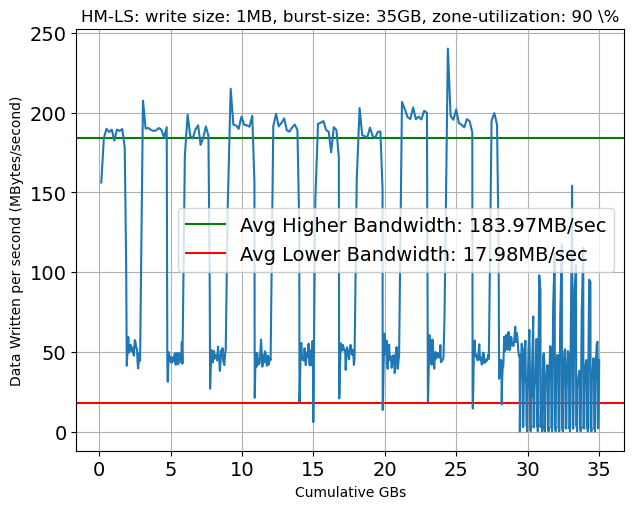

In [7]:
data_array = filtered_df_grouped['data_written_bytes'].values.reshape(-1, 1)
kmeans = KMeans(n_clusters=2)
kmeans.fit(data_array)
# Get the cluster centers
cluster_centers = kmeans.cluster_centers_.flatten()
# Sort cluster centers to get the lowest and highest modes
cluster_centers.sort()
# Calculate the average of each mode
average_mode1 = cluster_centers[0]
average_mode2 = cluster_centers[1]
print("Average1: " + str(round(average_mode1, )))
print("Average2: " + str(round(average_mode2, )))
avg_bw_str1 = str(round(average_mode1, 2)) + 'MB/sec'
avg_bw_str2 = str(round(average_mode2, 2)) + 'MB/sec'
fig, ax = plt.subplots()
plt.axhline(y=average_mode2, color='g', linestyle='-', label='Avg Higher Bandwidth: ' + avg_bw_str2)
plt.axhline(y=average_mode1, color='r', linestyle='-', label='Avg Lower Bandwidth: ' + avg_bw_str1)

# Plot vertical lines at x where y is higher than the threshold

#cid = plt.figure().canvas.mpl_connect('button_press_event', mouse_event)

plt.legend(loc='center right', fontsize=14)
# Plot the data size over time for each resolution
#plt.figure(figsize=(8, 6), dpi=80)
plt.rc('text', usetex=True)
plt.rc('font', family='serif')
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
#plt.xlim(0, 8000)
#plt.ylim(0, 250)
plt.tight_layout()
plt.plot(filtered_df_grouped['cumulative_gb'], filtered_df_grouped['data_written_bytes'])
#plt.plot(df_grouped.index, df_grouped['data_written_bytes'])
plt.xlabel('Cumulative GBs')
plt.ylabel('Data Written per second (MBytes/second)')
plt.grid(True)  # Optionally, add grid lines
plt.title("HM-LS: write size: 1MB, burst-size: 35GB, zone-utilization: 90 \%")
    
plt.savefig('/home/surbhi/github/surbhi-plots/new/LSDM/1M_90Util_9010_lsdm_CGBW.png', bbox_inches='tight')
plt.show()


17.97645288860577
183.96519604318345


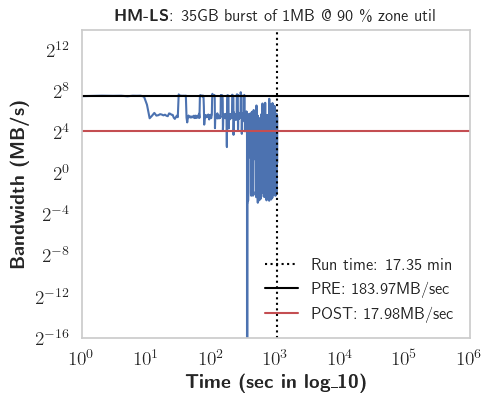

In [8]:
#now plot the data with seaborn
#remove the grid and use white background
sns.set_theme(style="whitegrid")
plt.figure(figsize=(5, 4))
plt.grid(False)
ax = sns.lineplot(x='index', y='data_written_bytes', data=filtered_df_grouped)
plt.title(r"$\textbf{HM-LS}$: 35GB burst of 1MB @ 90 \% zone util")

common_yticks = [2**i for i in range(-16, 14, 2)]
plt.yticks(common_yticks, [str(2**i) for i in range(-16, 14, 2)])
# Custom formatter to display ticks as powers of 2
def log2_format(y, pos):
    return f'$2^{{{int(np.log2(y))}}}$' if y > 0 else '0'

lowest_power_of_2 = 2 ** -16
ax.set_ylim(lowest_power_of_2 , 2**14)
ax.get_yaxis().set_major_formatter(ticker.FuncFormatter(log2_format))
plt.yscale('log', base=2)
#set x-axis to log scale
ax.set_xscale('log')
#set y-axis to log base 2 scale
ax.set_yscale('log', base=2)
plt.ylabel(r'$\textbf{Bandwidth (MB/s)}$', fontsize=14)

# Custom formatter to display ticks as powers of 10
def log10_format(y, pos):
    return f'$10^{{{int(np.log10(y))}}}$' if y > 0 else '0'

common_ticks = [10**0, 10**1, 10**2, 10**3, 10**4, 10**5, 10**6]
ax.get_xaxis().set_major_formatter(ticker.FuncFormatter(log10_format))
ax.set_xlim(10**0, 10**5)
plt.xticks(common_ticks,fontsize=14)
xmax = filtered_df_grouped.index.max()
# Add a vertical line at the end of the experiment
xmin = round(int(xmax)/60, 2)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel(r'$\textbf{Time (sec in log_10)}$', fontsize=14)

print(str(average_mode1))
print(str(average_mode2))
ax.axvline(x=xmax, color='black', linestyle=':', label='Run time: ' + str(xmin) + ' min')
plt.axhline(y=average_mode2, color='black', linestyle='-', label='PRE: ' + avg_bw_str2)
plt.axhline(y=average_mode1, color='r', linestyle='-', label='POST: ' + avg_bw_str1)

plt.legend(loc='lower right', fontsize=12, frameon=False)
  

plt.savefig('/home/surbhi/Downloads/1M_90Util_9010_lsdm_BW.pdf', bbox_inches='tight', format="pdf")

46080


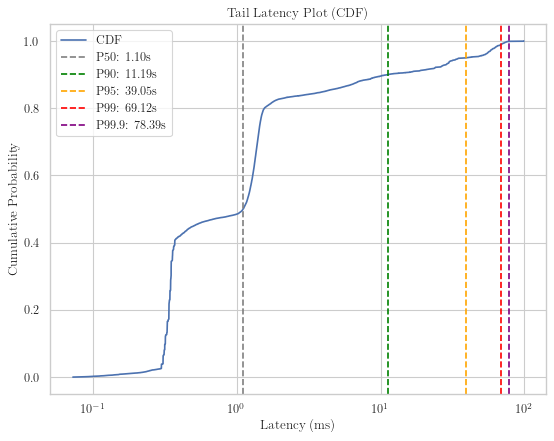

1.102185875
99.480822018


In [9]:
df = pd.read_csv('/home/surbhi/measurements/new/worst_case/lsdm/90Util/1MB/8TB/70-30-LBA/lat_log_avg_lat.1.log', names=names_latency)
df['duration'] = df['duration']/1e9 #convert ns to seconds

df_filtered = df[0: 1042235]

# Plot the data
# Create the line plot
plt.figure(figsize=(8, 6), dpi=80)
plt.rc('text', usetex=True)
plt.rc('font', family='serif')
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.grid(True)  # Optionally, add grid lines
#plt.semilogx()
latencies = df_filtered['duration'].to_numpy()
latencies_sorted = np.sort(latencies)
print(len(latencies_sorted))

# Calculate percentiles
p50 = np.percentile(latencies, 50)
p90 = np.percentile(latencies, 90)
p95 = np.percentile(latencies, 95)
p99 = np.percentile(latencies, 99)
p99_9 = np.percentile(latencies, 99.9)
#cdf_values = np.arange(1, len(latencies) + 1) / len(latencies)
plt.plot(latencies_sorted, np.linspace(0, 1, len(latencies_sorted)), label='CDF')
#plt.plot(latencies_sorted, cdf_values)

# Mark key percentiles
plt.axvline(x=p50, color='gray', linestyle='--', label=f'P50: {p50:.2f}s')
plt.axvline(x=p90, color='green', linestyle='--', label=f'P90: {p90:.2f}s')
plt.axvline(x=p95, color='orange', linestyle='--', label=f'P95: {p95:.2f}s')
plt.axvline(x=p99, color='red', linestyle='--', label=f'P99: {p99:.2f}s')
plt.axvline(x=p99_9, color='purple', linestyle='--', label=f'P99.9: {p99_9:.2f}s')

plt.title('Tail Latency Plot (CDF)')
plt.xlabel('Latency (ms)')
plt.ylabel('Cumulative Probability')
plt.grid(True)
plt.legend()
plt.xscale('log') # Often useful for heavy-tailed distributions
plt.show()






# Add labels and title
#plt.xlabel('Percentile', fontsize=16)

#plt.ylabel('Cumulative probability Latency', fontsize=16)
# plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
#plt.title("Tail Latency at Specific Percentiles", fontsize=16)
#df.describe()
print(str(df['duration'].median()))
print(str(df['duration'].max()))

35840


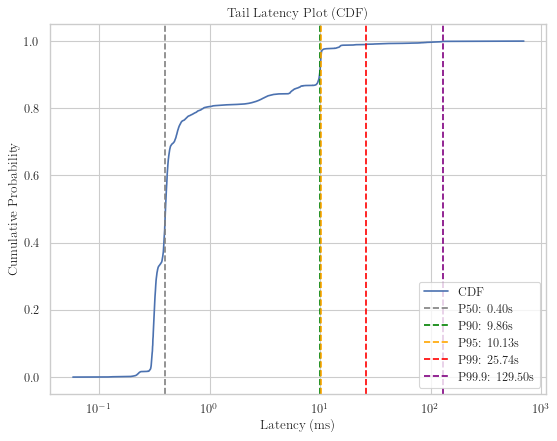

0.3980362285
693.189204627


In [10]:
df = pd.read_csv('/home/surbhi/measurements/new/worst_case/STL/1M/70-30-LBA/90Util/lat_log_avg_lat.1.log', names=names_latency)
df['duration'] = df['duration']/1e9 #convert ns to seconds

# Plot the data
# Create the line plot
plt.figure(figsize=(8, 6), dpi=80)
plt.rc('text', usetex=True)
plt.rc('font', family='serif')
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.grid(True)  # Optionally, add grid lines
#plt.semilogx()
latencies = df['duration'].to_numpy()
latencies_sorted = np.sort(latencies)
print(len(latencies_sorted))

# Calculate percentiles
p50 = np.percentile(latencies, 50)
p90 = np.percentile(latencies, 90)
p95 = np.percentile(latencies, 95)
p99 = np.percentile(latencies, 99)
p99_9 = np.percentile(latencies, 99.9)
#cdf_values = np.arange(1, len(latencies) + 1) / len(latencies)
plt.plot(latencies_sorted, np.linspace(0, 1, len(latencies_sorted)), label='CDF')
#plt.plot(latencies_sorted, cdf_values)

# Mark key percentiles
plt.axvline(x=p50, color='gray', linestyle='--', label=f'P50: {p50:.2f}s')
plt.axvline(x=p90, color='green', linestyle='--', label=f'P90: {p90:.2f}s')
plt.axvline(x=p95, color='orange', linestyle='--', label=f'P95: {p95:.2f}s')
plt.axvline(x=p99, color='red', linestyle='--', label=f'P99: {p99:.2f}s')
plt.axvline(x=p99_9, color='purple', linestyle='--', label=f'P99.9: {p99_9:.2f}s')

plt.title('Tail Latency Plot (CDF)')
plt.xlabel('Latency (ms)')
plt.ylabel('Cumulative Probability')
plt.grid(True)
plt.legend()
plt.xscale('log') # Often useful for heavy-tailed distributions
plt.show()






# Add labels and title
#plt.xlabel('Percentile', fontsize=16)

#plt.ylabel('Cumulative probability Latency', fontsize=16)
# plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
#plt.title("Tail Latency at Specific Percentiles", fontsize=16)
#df.describe()
print(str(df['duration'].median()))
print(str(df['duration'].max()))

In [11]:
# Define a custom grouping function
  
names_latency=['submission_time', 'duration', 'op2', 'write_size', 'op3']
columns = ['submission_time', 'duration', 'write_size']

# Step 1: Read the CSV file into a Pandas DataFrame
df = pd.read_csv('/home/surbhi/measurements/new/worst_case/STL/1M/70-30-LBA/75Util/lat_log_avg_lat.1.log', names=names_latency)
#df = pd.read_csv('/home/surbhi/measurements/worst_case/lsdm/90Util/1MB/8TB/90-10-LBA/lat_log_avg_lat.1.log', names=names_latency)
df['submission_time'] = np.floor(df['submission_time'] - df.iloc[0].submission_time)
df['duration'] = df['duration']/1e6 #convert ns to ms
df['completion_time'] = df['submission_time'] + df['duration']

In [12]:
# Step 3: Determine the start and end time of the entire test
start_time = int(df['submission_time'].min())
end_time = int(df['completion_time'].max())


# Step 4: Create new DataFrames to represent each  millisecond between the start and end time of the entire test
data_written_ms = pd.DataFrame(index=range(start_time, end_time + 1, 1), columns=['data_written_bytes'])
data_written_ms['data_written_bytes'] = 0


# Step 5: Iterate through each write request, calculate the data size for each time interval, and update the corresponding entries in the DataFrames
for index, row in df.iterrows():
    duration = row['duration']
    start = int(row['submission_time'])
    end = start+math.floor(duration)
    
    payload = (1024 * 1024)
    write_rate_per_ms = payload / max(duration, 1.)
    assert(write_rate_per_ms <= payload)
    residue = payload - write_rate_per_ms * math.floor(duration)
    assert (payload >= (write_rate_per_ms * math.floor(duration)))
    data_written_ms.loc[start:end-1] += write_rate_per_ms
    # residue could be zero when last == end
    data_written_ms.loc[end] += residue

print(index)
data_written_ms.reset_index(drop=True, inplace=True)

/tmp/ipykernel_22753/3907914144.py:22: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[19628.03847296 19628.03847296 19628.03847296 19628.03847296
 19628.03847296 19628.03847296 19628.03847296 19628.03847296
 19628.03847296 19628.03847296 19628.03847296 19628.03847296
 19628.03847296 19628.03847296 19628.03847296 19628.03847296
 19628.03847296 19628.03847296 19628.03847296 19628.03847296
 19628.03847296 19628.03847296 19628.03847296 19628.03847296
 19628.03847296 19628.03847296 19628.03847296 19628.03847296
 19628.03847296 19628.03847296 19628.03847296 19628.03847296
 19628.03847296 19628.03847296 19628.03847296 19628.03847296
 19628.03847296 19628.03847296 19628.03847296 19628.03847296
 19628.03847296 19628.03847296 19628.03847296 19628.03847296
 19628.03847296 19628.03847296 19628.03847296 19628.03847296
 19628.03847296 19628.03847296 19628.03847296 19628.03847296
 19628.03847296]' has dtype incompatible with int6

35839


In [13]:
#assert math.floor(data_written_ms.data_written_bytes.sum()) == (len(df)*1048576)
print(math.floor(data_written_ms.data_written_bytes.sum()))
print(len(df) * 1048576)
df_test = data_written_ms[data_written_ms['data_written_bytes'].cumsum() < (35 * 1024 * 1024 * 1024)]
print(len(df_test))
# print(data_written_ms.describe())
# print(math.floor(filtered_data_written_ms.data_written_bytes.sum()))


37580963839
37580963840
2367421


In [14]:
chunk_size = 10000
results = []
#use custom grouping to convert index from representing ms to seconds
for i in range(0, len(data_written_ms), chunk_size):
    chunk = data_written_ms.iloc[i:i+chunk_size]
    result = chunk.groupby(custom_grouping).sum()
    results.append(result)

df_grouped = pd.concat(results)

# Reset the index to make it a regular column
df_grouped.reset_index(inplace=True)
df_grouped['cumulative_gb'] = df_grouped['data_written_bytes'].cumsum() / (1024 ** 3)
df_grouped['data_written_bytes'] = df_grouped['data_written_bytes'] / (1024 ** 2) 
#
#data_array = df_grouped['data_written_bytes'].values.reshape(-1, 1)
#print(df_grouped.describe())
#print(df_grouped.info())
print("Min Idx: \n" + str(df_grouped['data_written_bytes'].idxmin()))

Min Idx: 
1572


In [15]:
filtered_df_grouped = df_grouped[df_grouped['cumulative_gb'] < 40]
print(filtered_df_grouped.columns)

Index(['index', 'data_written_bytes', 'cumulative_gb'], dtype='object')


Average1: 3
Average2: 125


<>:40: SyntaxWarning: invalid escape sequence '\%'
<>:40: SyntaxWarning: invalid escape sequence '\%'
/tmp/ipykernel_22753/4241942114.py:40: SyntaxWarning: invalid escape sequence '\%'
  plt.title("DM-Hybrid: write size: 1MB, burst-size: 35GB, zone-utilization: 75 \%")


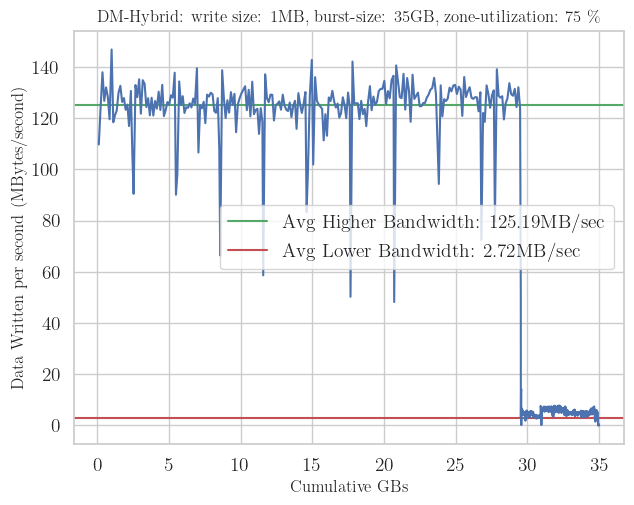

In [16]:
data_array = filtered_df_grouped['data_written_bytes'].values.reshape(-1, 1)
kmeans = KMeans(n_clusters=2)
kmeans.fit(data_array)
# Get the cluster centers
cluster_centers = kmeans.cluster_centers_.flatten()
# Sort cluster centers to get the lowest and highest modes
cluster_centers.sort()
# Calculate the average of each mode
average_mode1 = cluster_centers[0]
average_mode2 = cluster_centers[1]
print("Average1: " + str(round(average_mode1, )))
print("Average2: " + str(round(average_mode2, )))
avg_bw_str1 = str(round(average_mode1, 2)) + 'MB/sec'
avg_bw_str2 = str(round(average_mode2, 2)) + 'MB/sec'
fig, ax = plt.subplots()
plt.axhline(y=average_mode2, color='g', linestyle='-', label='Avg Higher Bandwidth: ' + avg_bw_str2)
plt.axhline(y=average_mode1, color='r', linestyle='-', label='Avg Lower Bandwidth: ' + avg_bw_str1)

# Plot vertical lines at x where y is higher than the threshold

#cid = plt.figure().canvas.mpl_connect('button_press_event', mouse_event)

plt.legend(loc='center right', fontsize=14)
# Plot the data size over time for each resolution
#plt.figure(figsize=(8, 6), dpi=80)
plt.rc('text', usetex=True)
plt.rc('font', family='serif')
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
#plt.xlim(0, 8000)
#plt.ylim(0, 250)
plt.tight_layout()
plt.plot(filtered_df_grouped['cumulative_gb'], filtered_df_grouped['data_written_bytes'])
#plt.plot(df_grouped.index, df_grouped['data_written_bytes'])
plt.xlabel('Cumulative GBs')
plt.ylabel('Data Written per second (MBytes/second)')
plt.grid(True)  # Optionally, add grid lines
plt.title("DM-Hybrid: write size: 1MB, burst-size: 35GB, zone-utilization: 75 \%")
    
plt.savefig('/home/surbhi/github/surbhi-plots/new/STL/1M_75Util_7030_dmhybrid_CGBW.png', bbox_inches='tight')
plt.show()


2.7230035944629805
125.18936812909502


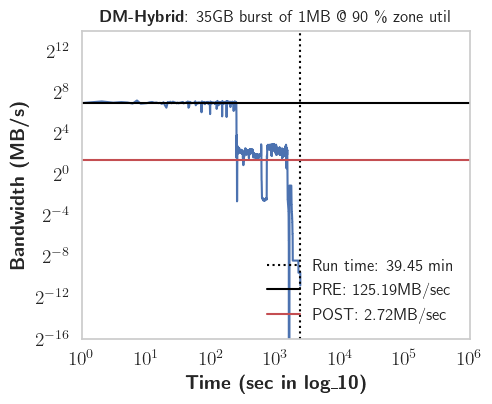

In [17]:
#now plot the data with seaborn
#remove the grid and use white background
sns.set_theme(style="whitegrid")
plt.figure(figsize=(5, 4))
plt.grid(False)
ax = sns.lineplot(x='index', y='data_written_bytes', data=filtered_df_grouped)
plt.title(r"$\textbf{DM-Hybrid}$: 35GB burst of 1MB @ 90 \% zone util")

common_yticks = [2**i for i in range(-16, 14, 2)]
plt.yticks(common_yticks, [str(2**i) for i in range(-16, 14, 2)])
# Custom formatter to display ticks as powers of 2
def log2_format(y, pos):
    return f'$2^{{{int(np.log2(y))}}}$' if y > 0 else '0'

lowest_power_of_2 = 2 ** -16
ax.set_ylim(lowest_power_of_2 , 2**14)
ax.get_yaxis().set_major_formatter(ticker.FuncFormatter(log2_format))
plt.yscale('log', base=2)
#set x-axis to log scale
ax.set_xscale('log')
#set y-axis to log base 2 scale
ax.set_yscale('log', base=2)
plt.ylabel(r'$\textbf{Bandwidth (MB/s)}$', fontsize=14)

# Custom formatter to display ticks as powers of 10
def log10_format(y, pos):
    return f'$10^{{{int(np.log10(y))}}}$' if y > 0 else '0'

common_ticks = [10**0, 10**1, 10**2, 10**3, 10**4, 10**5, 10**6]
ax.get_xaxis().set_major_formatter(ticker.FuncFormatter(log10_format))
ax.set_xlim(10**0, 10**5)
plt.xticks(common_ticks,fontsize=14)
xmax = filtered_df_grouped.index.max()
# Add a vertical line at the end of the experiment
xmin = round(int(xmax)/60, 2)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel(r'$\textbf{Time (sec in log_10)}$', fontsize=14)

print(str(average_mode1))
print(str(average_mode2))
ax.axvline(x=xmax, color='black', linestyle=':', label='Run time: ' + str(xmin) + ' min')
plt.axhline(y=average_mode2, color='black', linestyle='-', label='PRE: ' + avg_bw_str2)
plt.axhline(y=average_mode1, color='r', linestyle='-', label='POST: ' + avg_bw_str1)

plt.legend(loc='lower right', fontsize=12, frameon=False)
  

plt.savefig('/home/surbhi/Downloads/1M_75Util_7030_dmhybrid_BW.pdf', bbox_inches='tight', format="pdf")

35840


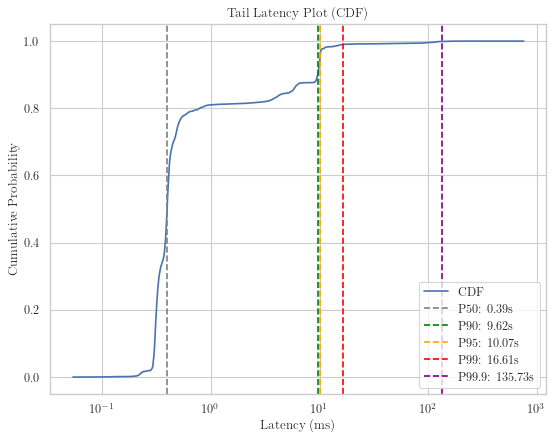

0.39425443000000004
762.330782499


In [18]:
df = pd.read_csv('/home/surbhi/measurements/new/worst_case/STL/1M/70-30-LBA/75Util/lat_log_avg_lat.1.log', names=names_latency)
df['duration'] = df['duration']/1e9 #convert ns to seconds

df_filtered = df[0: 1042235]

# Plot the data
# Create the line plot
plt.figure(figsize=(8, 6), dpi=80)
plt.rc('text', usetex=True)
plt.rc('font', family='serif')
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.grid(True)  # Optionally, add grid lines
#plt.semilogx()
latencies = df_filtered['duration'].to_numpy()
latencies_sorted = np.sort(latencies)
print(len(latencies_sorted))

# Calculate percentiles
p50 = np.percentile(latencies, 50)
p90 = np.percentile(latencies, 90)
p95 = np.percentile(latencies, 95)
p99 = np.percentile(latencies, 99)
p99_9 = np.percentile(latencies, 99.9)
#cdf_values = np.arange(1, len(latencies) + 1) / len(latencies)
plt.plot(latencies_sorted, np.linspace(0, 1, len(latencies_sorted)), label='CDF')
#plt.plot(latencies_sorted, cdf_values)

# Mark key percentiles
plt.axvline(x=p50, color='gray', linestyle='--', label=f'P50: {p50:.2f}s')
plt.axvline(x=p90, color='green', linestyle='--', label=f'P90: {p90:.2f}s')
plt.axvline(x=p95, color='orange', linestyle='--', label=f'P95: {p95:.2f}s')
plt.axvline(x=p99, color='red', linestyle='--', label=f'P99: {p99:.2f}s')
plt.axvline(x=p99_9, color='purple', linestyle='--', label=f'P99.9: {p99_9:.2f}s')

plt.title('Tail Latency Plot (CDF)')
plt.xlabel('Latency (ms)')
plt.ylabel('Cumulative Probability')
plt.grid(True)
plt.legend()
plt.xscale('log') # Often useful for heavy-tailed distributions
plt.show()






# Add labels and title
#plt.xlabel('Percentile', fontsize=16)

#plt.ylabel('Cumulative probability Latency', fontsize=16)
# plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
#plt.title("Tail Latency at Specific Percentiles", fontsize=16)
#df.describe()
print(str(df['duration'].median()))
print(str(df['duration'].max()))

35840


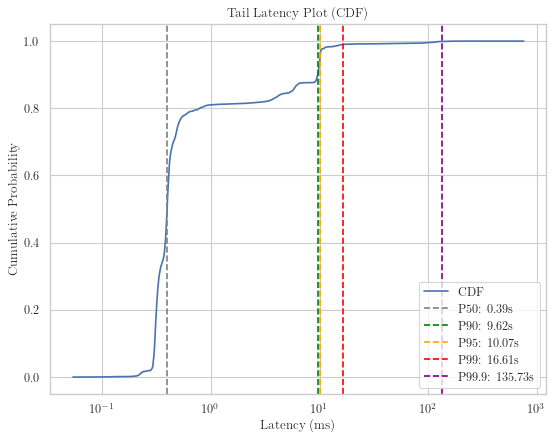

0.39425443000000004
762.330782499


In [19]:
df = pd.read_csv('/home/surbhi/measurements/new/worst_case/STL/1M/70-30-LBA/75Util/lat_log_avg_lat.1.log', names=names_latency)
df['duration'] = df['duration']/1e9 #convert ns to seconds

# Plot the data
# Create the line plot
plt.figure(figsize=(8, 6), dpi=80)
plt.rc('text', usetex=True)
plt.rc('font', family='serif')
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.grid(True)  # Optionally, add grid lines
#plt.semilogx()
latencies = df['duration'].to_numpy()
latencies_sorted = np.sort(latencies)
print(len(latencies_sorted))

# Calculate percentiles
p50 = np.percentile(latencies, 50)
p90 = np.percentile(latencies, 90)
p95 = np.percentile(latencies, 95)
p99 = np.percentile(latencies, 99)
p99_9 = np.percentile(latencies, 99.9)
#cdf_values = np.arange(1, len(latencies) + 1) / len(latencies)
plt.plot(latencies_sorted, np.linspace(0, 1, len(latencies_sorted)), label='CDF')
#plt.plot(latencies_sorted, cdf_values)

# Mark key percentiles
plt.axvline(x=p50, color='gray', linestyle='--', label=f'P50: {p50:.2f}s')
plt.axvline(x=p90, color='green', linestyle='--', label=f'P90: {p90:.2f}s')
plt.axvline(x=p95, color='orange', linestyle='--', label=f'P95: {p95:.2f}s')
plt.axvline(x=p99, color='red', linestyle='--', label=f'P99: {p99:.2f}s')
plt.axvline(x=p99_9, color='purple', linestyle='--', label=f'P99.9: {p99_9:.2f}s')

plt.title('Tail Latency Plot (CDF)')
plt.xlabel('Latency (ms)')
plt.ylabel('Cumulative Probability')
plt.grid(True)
plt.legend()
plt.xscale('log') # Often useful for heavy-tailed distributions
plt.show()






# Add labels and title
#plt.xlabel('Percentile', fontsize=16)

#plt.ylabel('Cumulative probability Latency', fontsize=16)
# plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
#plt.title("Tail Latency at Specific Percentiles", fontsize=16)
#df.describe()
print(str(df['duration'].median()))
print(str(df['duration'].max()))

<>:109: SyntaxWarning: invalid escape sequence '\%'
<>:382: SyntaxWarning: invalid escape sequence '\%'
<>:109: SyntaxWarning: invalid escape sequence '\%'
<>:382: SyntaxWarning: invalid escape sequence '\%'
/tmp/ipykernel_22753/1553265985.py:109: SyntaxWarning: invalid escape sequence '\%'
  plt.title("HM-LS: write size: 1MB, burst-size: 35GB, zone-utilization: 90 \%")
/tmp/ipykernel_22753/1553265985.py:382: SyntaxWarning: invalid escape sequence '\%'
  plt.title("DM-Hybrid: write size: 1MB, burst-size: 35GB, zone-utilization: 75 \%")
/tmp/ipykernel_22753/1553265985.py:35: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[4131.82049498 4131.82049498 4131.82049498 4131.82049498 4131.82049498
 4131.82049498 4131.82049498 4131.82049498 4131.82049498 4131.82049498
 4131.82049498 4131.82049498 4131.82049498 4131.82049498 4131.82049498
 4131.82049498 4131.82049498 4131.82049498 4131.82049498 4131.82049498
 4131.82049498 41

35839
37580963840
37580963840
1392813
Min Idx: 
242
Index(['index', 'data_written_bytes', 'cumulative_gb'], dtype='object')
Average1: 6
Average2: 121


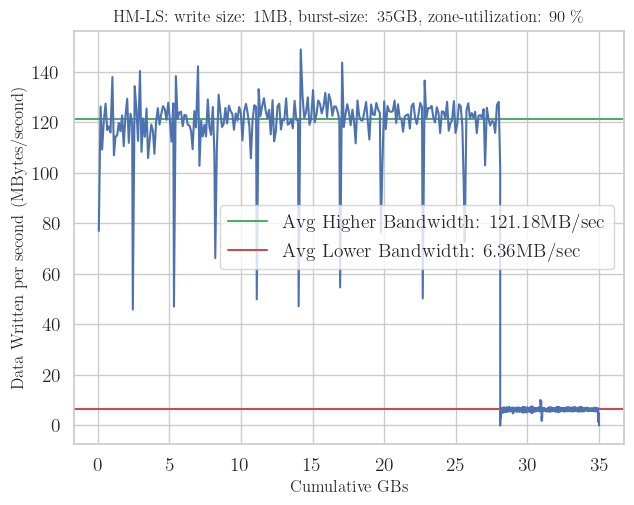

6.357563036764802
121.18273192947382
46080


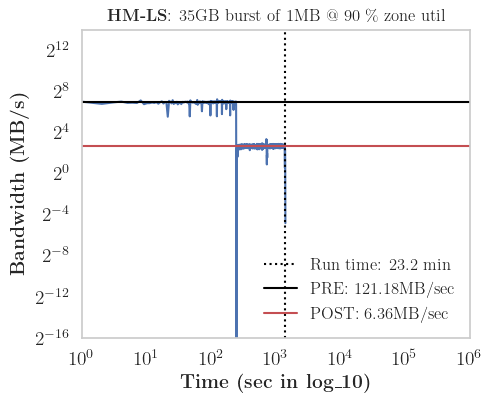

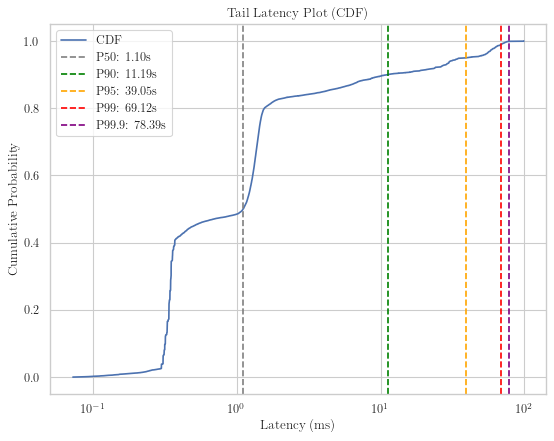

1.102185875
99.480822018
35840


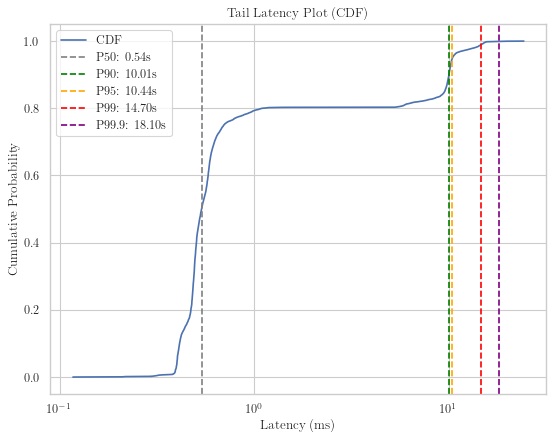

0.5359618500000001
24.287231526


/tmp/ipykernel_22753/1553265985.py:308: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[4131.82049498 4131.82049498 4131.82049498 4131.82049498 4131.82049498
 4131.82049498 4131.82049498 4131.82049498 4131.82049498 4131.82049498
 4131.82049498 4131.82049498 4131.82049498 4131.82049498 4131.82049498
 4131.82049498 4131.82049498 4131.82049498 4131.82049498 4131.82049498
 4131.82049498 4131.82049498 4131.82049498 4131.82049498 4131.82049498
 4131.82049498 4131.82049498 4131.82049498 4131.82049498 4131.82049498
 4131.82049498 4131.82049498 4131.82049498 4131.82049498 4131.82049498
 4131.82049498 4131.82049498 4131.82049498 4131.82049498 4131.82049498
 4131.82049498 4131.82049498 4131.82049498 4131.82049498 4131.82049498
 4131.82049498 4131.82049498 4131.82049498 4131.82049498 4131.82049498
 4131.82049498 4131.82049498 4131.82049498 4131.82049498 4131.82049498
 4131.82049498 4131.82049498 4131.82049498 4131.82049498 4131

35839
37580963840
37580963840
1392813
Min Idx: 
242
Index(['index', 'data_written_bytes', 'cumulative_gb'], dtype='object')
Average1: 6
Average2: 121


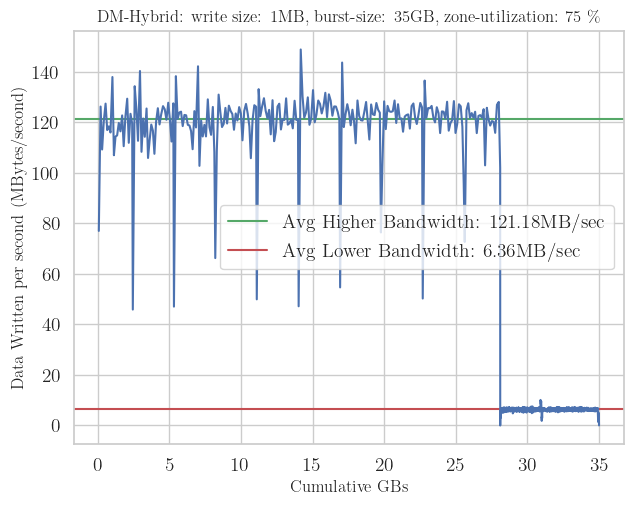

6.357563036764802
121.18273192947382
35840


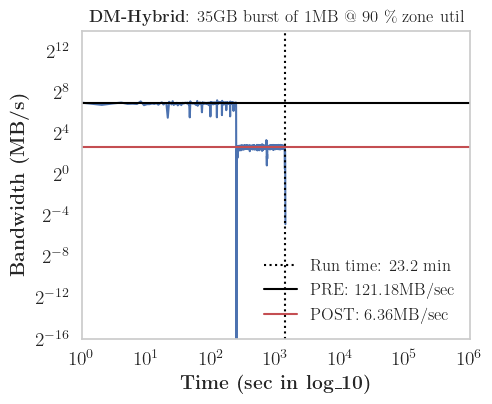

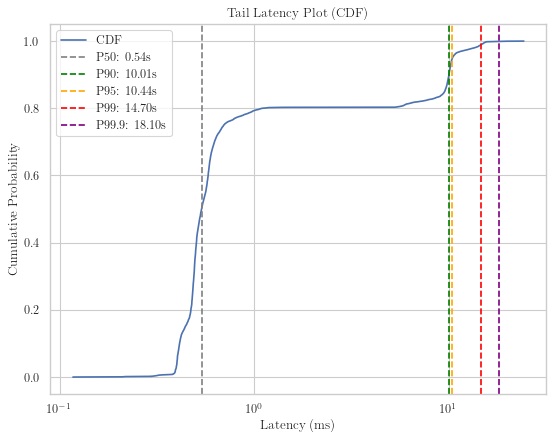

0.5359618500000001
24.287231526
35840


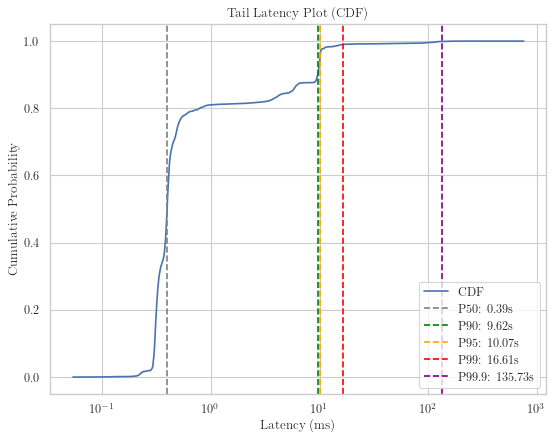

0.39425443000000004
762.330782499


In [21]:
names_bw=['time', 'bw', 'op1', 'size', 'op2' ]
names_latency=['time', 'latency', 'op2', 'write_size', 'op3']
# Define a custom grouping function
  
names_latency=['submission_time', 'duration', 'op2', 'write_size', 'op3']
columns = ['submission_time', 'duration', 'write_size']

# Step 1: Read the CSV file into a Pandas DataFrame
df = pd.read_csv('/home/surbhi/measurements/new/worst_case/STL/1M/70-30-LBA/25Util/lat_log_avg_lat.1.log', names=names_latency)
#df = pd.read_csv('/home/surbhi/measurements/worst_case/lsdm/90Util/1MB/8TB/90-10-LBA/lat_log_avg_lat.1.log', names=names_latency)
df['submission_time'] = np.floor(df['submission_time'] - df.iloc[0].submission_time)
df['duration'] = df['duration']/1e6 #convert ns to ms
df['completion_time'] = df['submission_time'] + df['duration']
# Step 3: Determine the start and end time of the entire test
start_time = int(df['submission_time'].min())
end_time = int(df['completion_time'].max())


# Step 4: Create new DataFrames to represent each  millisecond between the start and end time of the entire test
data_written_ms = pd.DataFrame(index=range(start_time, end_time + 1, 1), columns=['data_written_bytes'])
data_written_ms['data_written_bytes'] = 0


# Step 5: Iterate through each write request, calculate the data size for each time interval, and update the corresponding entries in the DataFrames
for index, row in df.iterrows():
    duration = row['duration']
    start = int(row['submission_time'])
    end = start+math.floor(duration)
    
    payload = (1024 * 1024)
    write_rate_per_ms = payload / max(duration, 1.)
    assert(write_rate_per_ms <= payload)
    residue = payload - write_rate_per_ms * math.floor(duration)
    assert (payload >= (write_rate_per_ms * math.floor(duration)))
    data_written_ms.loc[start:end-1] += write_rate_per_ms
    # residue could be zero when last == end
    data_written_ms.loc[end] += residue

print(index)
data_written_ms.reset_index(drop=True, inplace=True)
#assert math.floor(data_written_ms.data_written_bytes.sum()) == (len(df)*1048576)
print(math.floor(data_written_ms.data_written_bytes.sum()))
print(len(df) * 1048576)
df_test = data_written_ms[data_written_ms['data_written_bytes'].cumsum() < (35 * 1024 * 1024 * 1024)]
print(len(df_test))
# print(data_written_ms.describe())
# print(math.floor(filtered_data_written_ms.data_written_bytes.sum()))

chunk_size = 10000
results = []
#use custom grouping to convert index from representing ms to seconds
for i in range(0, len(data_written_ms), chunk_size):
    chunk = data_written_ms.iloc[i:i+chunk_size]
    result = chunk.groupby(custom_grouping).sum()
    results.append(result)

df_grouped = pd.concat(results)

# Reset the index to make it a regular column
df_grouped.reset_index(inplace=True)
df_grouped['cumulative_gb'] = df_grouped['data_written_bytes'].cumsum() / (1024 ** 3)
df_grouped['data_written_bytes'] = df_grouped['data_written_bytes'] / (1024 ** 2) 
#
#data_array = df_grouped['data_written_bytes'].values.reshape(-1, 1)
#print(df_grouped.describe())
#print(df_grouped.info())
print("Min Idx: \n" + str(df_grouped['data_written_bytes'].idxmin()))
filtered_df_grouped = df_grouped[df_grouped['cumulative_gb'] < 35]
print(filtered_df_grouped.columns)
data_array = filtered_df_grouped['data_written_bytes'].values.reshape(-1, 1)
kmeans = KMeans(n_clusters=2)
kmeans.fit(data_array)
# Get the cluster centers
cluster_centers = kmeans.cluster_centers_.flatten()
# Sort cluster centers to get the lowest and highest modes
cluster_centers.sort()
# Calculate the average of each mode
average_mode1 = cluster_centers[0]
average_mode2 = cluster_centers[1]
print("Average1: " + str(round(average_mode1, )))
print("Average2: " + str(round(average_mode2, )))
avg_bw_str1 = str(round(average_mode1, 2)) + 'MB/sec'
avg_bw_str2 = str(round(average_mode2, 2)) + 'MB/sec'
fig, ax = plt.subplots()
plt.axhline(y=average_mode2, color='g', linestyle='-', label='Avg Higher Bandwidth: ' + avg_bw_str2)
plt.axhline(y=average_mode1, color='r', linestyle='-', label='Avg Lower Bandwidth: ' + avg_bw_str1)

# Plot vertical lines at x where y is higher than the threshold

#cid = plt.figure().canvas.mpl_connect('button_press_event', mouse_event)

plt.legend(loc='center right', fontsize=14)
# Plot the data size over time for each resolution
#plt.figure(figsize=(8, 6), dpi=80)
plt.rc('text', usetex=True)
plt.rc('font', family='serif')
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
#plt.xlim(0, 8000)
#plt.ylim(0, 250)
plt.tight_layout()
plt.plot(filtered_df_grouped['cumulative_gb'], filtered_df_grouped['data_written_bytes'])
#plt.plot(df_grouped.index, df_grouped['data_written_bytes'])
plt.xlabel('Cumulative GBs')
plt.ylabel('Data Written per second (MBytes/second)')
plt.grid(True)  # Optionally, add grid lines
plt.title("HM-LS: write size: 1MB, burst-size: 35GB, zone-utilization: 90 \%")
    
plt.savefig('/home/surbhi/github/surbhi-plots/new/LSDM/1M_90Util_9010_lsdm_CGBW.png', bbox_inches='tight')
plt.show()

#now plot the data with seaborn
#remove the grid and use white background
sns.set_theme(style="whitegrid")
plt.figure(figsize=(5, 4))
plt.grid(False)
ax = sns.lineplot(x='index', y='data_written_bytes', data=filtered_df_grouped)
plt.title(r"$\textbf{HM-LS}$: 35GB burst of 1MB @ 90 \% zone util")

common_yticks = [2**i for i in range(-16, 14, 2)]
plt.yticks(common_yticks, [str(2**i) for i in range(-16, 14, 2)])
# Custom formatter to display ticks as powers of 2
def log2_format(y, pos):
    return f'$2^{{{int(np.log2(y))}}}$' if y > 0 else '0'

lowest_power_of_2 = 2 ** -16
ax.set_ylim(lowest_power_of_2 , 2**14)
ax.get_yaxis().set_major_formatter(ticker.FuncFormatter(log2_format))
plt.yscale('log', base=2)
#set x-axis to log scale
ax.set_xscale('log')
#set y-axis to log base 2 scale
ax.set_yscale('log', base=2)
plt.ylabel(r'$\textbf{Bandwidth (MB/s)}$', fontsize=14)

# Custom formatter to display ticks as powers of 10
def log10_format(y, pos):
    return f'$10^{{{int(np.log10(y))}}}$' if y > 0 else '0'

common_ticks = [10**0, 10**1, 10**2, 10**3, 10**4, 10**5, 10**6]
ax.get_xaxis().set_major_formatter(ticker.FuncFormatter(log10_format))
ax.set_xlim(10**0, 10**5)
plt.xticks(common_ticks,fontsize=14)
xmax = filtered_df_grouped.index.max()
# Add a vertical line at the end of the experiment
xmin = round(int(xmax)/60, 2)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel(r'$\textbf{Time (sec in log_10)}$', fontsize=14)

print(str(average_mode1))
print(str(average_mode2))
ax.axvline(x=xmax, color='black', linestyle=':', label='Run time: ' + str(xmin) + ' min')
plt.axhline(y=average_mode2, color='black', linestyle='-', label='PRE: ' + avg_bw_str2)
plt.axhline(y=average_mode1, color='r', linestyle='-', label='POST: ' + avg_bw_str1)

plt.legend(loc='lower right', fontsize=12, frameon=False)
  

plt.savefig('/home/surbhi/Downloads/1M_90Util_9010_lsdm_BW.pdf', bbox_inches='tight', format="pdf")
df = pd.read_csv('/home/surbhi/measurements/new/worst_case/lsdm/90Util/1MB/8TB/70-30-LBA/lat_log_avg_lat.1.log', names=names_latency)
df['duration'] = df['duration']/1e9 #convert ns to seconds

df_filtered = df[0: 1042235]

# Plot the data
# Create the line plot
plt.figure(figsize=(8, 6), dpi=80)
plt.rc('text', usetex=True)
plt.rc('font', family='serif')
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.grid(True)  # Optionally, add grid lines
#plt.semilogx()
latencies = df_filtered['duration'].to_numpy()
latencies_sorted = np.sort(latencies)
print(len(latencies_sorted))

# Calculate percentiles
p50 = np.percentile(latencies, 50)
p90 = np.percentile(latencies, 90)
p95 = np.percentile(latencies, 95)
p99 = np.percentile(latencies, 99)
p99_9 = np.percentile(latencies, 99.9)
#cdf_values = np.arange(1, len(latencies) + 1) / len(latencies)
plt.plot(latencies_sorted, np.linspace(0, 1, len(latencies_sorted)), label='CDF')
#plt.plot(latencies_sorted, cdf_values)

# Mark key percentiles
plt.axvline(x=p50, color='gray', linestyle='--', label=f'P50: {p50:.2f}s')
plt.axvline(x=p90, color='green', linestyle='--', label=f'P90: {p90:.2f}s')
plt.axvline(x=p95, color='orange', linestyle='--', label=f'P95: {p95:.2f}s')
plt.axvline(x=p99, color='red', linestyle='--', label=f'P99: {p99:.2f}s')
plt.axvline(x=p99_9, color='purple', linestyle='--', label=f'P99.9: {p99_9:.2f}s')

plt.title('Tail Latency Plot (CDF)')
plt.xlabel('Latency (ms)')
plt.ylabel('Cumulative Probability')
plt.grid(True)
plt.legend()
plt.xscale('log') # Often useful for heavy-tailed distributions
plt.show()






# Add labels and title
#plt.xlabel('Percentile', fontsize=16)

#plt.ylabel('Cumulative probability Latency', fontsize=16)
# plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
#plt.title("Tail Latency at Specific Percentiles", fontsize=16)
#df.describe()
print(str(df['duration'].median()))
print(str(df['duration'].max()))
df = pd.read_csv('/home/surbhi/measurements/new/worst_case/STL/1M/70-30-LBA/25Util/lat_log_avg_lat.1.log', names=names_latency)
df['duration'] = df['duration']/1e9 #convert ns to seconds

# Plot the data
# Create the line plot
plt.figure(figsize=(8, 6), dpi=80)
plt.rc('text', usetex=True)
plt.rc('font', family='serif')
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.grid(True)  # Optionally, add grid lines
#plt.semilogx()
latencies = df['duration'].to_numpy()
latencies_sorted = np.sort(latencies)
print(len(latencies_sorted))

# Calculate percentiles
p50 = np.percentile(latencies, 50)
p90 = np.percentile(latencies, 90)
p95 = np.percentile(latencies, 95)
p99 = np.percentile(latencies, 99)
p99_9 = np.percentile(latencies, 99.9)
#cdf_values = np.arange(1, len(latencies) + 1) / len(latencies)
plt.plot(latencies_sorted, np.linspace(0, 1, len(latencies_sorted)), label='CDF')
#plt.plot(latencies_sorted, cdf_values)

# Mark key percentiles
plt.axvline(x=p50, color='gray', linestyle='--', label=f'P50: {p50:.2f}s')
plt.axvline(x=p90, color='green', linestyle='--', label=f'P90: {p90:.2f}s')
plt.axvline(x=p95, color='orange', linestyle='--', label=f'P95: {p95:.2f}s')
plt.axvline(x=p99, color='red', linestyle='--', label=f'P99: {p99:.2f}s')
plt.axvline(x=p99_9, color='purple', linestyle='--', label=f'P99.9: {p99_9:.2f}s')

plt.title('Tail Latency Plot (CDF)')
plt.xlabel('Latency (ms)')
plt.ylabel('Cumulative Probability')
plt.grid(True)
plt.legend()
plt.xscale('log') # Often useful for heavy-tailed distributions
plt.show()






# Add labels and title
#plt.xlabel('Percentile', fontsize=16)

#plt.ylabel('Cumulative probability Latency', fontsize=16)
# plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
#plt.title("Tail Latency at Specific Percentiles", fontsize=16)
#df.describe()
print(str(df['duration'].median()))
print(str(df['duration'].max()))
# Define a custom grouping function
  
names_latency=['submission_time', 'duration', 'op2', 'write_size', 'op3']
columns = ['submission_time', 'duration', 'write_size']

# Step 1: Read the CSV file into a Pandas DataFrame
df = pd.read_csv('/home/surbhi/measurements/new/worst_case/STL/1M/70-30-LBA/25Util/lat_log_avg_lat.1.log', names=names_latency)
#df = pd.read_csv('/home/surbhi/measurements/worst_case/lsdm/90Util/1MB/8TB/90-10-LBA/lat_log_avg_lat.1.log', names=names_latency)
df['submission_time'] = np.floor(df['submission_time'] - df.iloc[0].submission_time)
df['duration'] = df['duration']/1e6 #convert ns to ms
df['completion_time'] = df['submission_time'] + df['duration']
# Step 3: Determine the start and end time of the entire test
start_time = int(df['submission_time'].min())
end_time = int(df['completion_time'].max())


# Step 4: Create new DataFrames to represent each  millisecond between the start and end time of the entire test
data_written_ms = pd.DataFrame(index=range(start_time, end_time + 1, 1), columns=['data_written_bytes'])
data_written_ms['data_written_bytes'] = 0


# Step 5: Iterate through each write request, calculate the data size for each time interval, and update the corresponding entries in the DataFrames
for index, row in df.iterrows():
    duration = row['duration']
    start = int(row['submission_time'])
    end = start+math.floor(duration)
    
    payload = (1024 * 1024)
    write_rate_per_ms = payload / max(duration, 1.)
    assert(write_rate_per_ms <= payload)
    residue = payload - write_rate_per_ms * math.floor(duration)
    assert (payload >= (write_rate_per_ms * math.floor(duration)))
    data_written_ms.loc[start:end-1] += write_rate_per_ms
    # residue could be zero when last == end
    data_written_ms.loc[end] += residue

print(index)
data_written_ms.reset_index(drop=True, inplace=True)
#assert math.floor(data_written_ms.data_written_bytes.sum()) == (len(df)*1048576)
print(math.floor(data_written_ms.data_written_bytes.sum()))
print(len(df) * 1048576)
df_test = data_written_ms[data_written_ms['data_written_bytes'].cumsum() < (35 * 1024 * 1024 * 1024)]
print(len(df_test))
# print(data_written_ms.describe())
# print(math.floor(filtered_data_written_ms.data_written_bytes.sum()))

chunk_size = 10000
results = []
#use custom grouping to convert index from representing ms to seconds
for i in range(0, len(data_written_ms), chunk_size):
    chunk = data_written_ms.iloc[i:i+chunk_size]
    result = chunk.groupby(custom_grouping).sum()
    results.append(result)

df_grouped = pd.concat(results)

# Reset the index to make it a regular column
df_grouped.reset_index(inplace=True)
df_grouped['cumulative_gb'] = df_grouped['data_written_bytes'].cumsum() / (1024 ** 3)
df_grouped['data_written_bytes'] = df_grouped['data_written_bytes'] / (1024 ** 2) 
#
#data_array = df_grouped['data_written_bytes'].values.reshape(-1, 1)
#print(df_grouped.describe())
#print(df_grouped.info())
print("Min Idx: \n" + str(df_grouped['data_written_bytes'].idxmin()))
filtered_df_grouped = df_grouped[df_grouped['cumulative_gb'] < 40]
print(filtered_df_grouped.columns)
data_array = filtered_df_grouped['data_written_bytes'].values.reshape(-1, 1)
kmeans = KMeans(n_clusters=2)
kmeans.fit(data_array)
# Get the cluster centers
cluster_centers = kmeans.cluster_centers_.flatten()
# Sort cluster centers to get the lowest and highest modes
cluster_centers.sort()
# Calculate the average of each mode
average_mode1 = cluster_centers[0]
average_mode2 = cluster_centers[1]
print("Average1: " + str(round(average_mode1, )))
print("Average2: " + str(round(average_mode2, )))
avg_bw_str1 = str(round(average_mode1, 2)) + 'MB/sec'
avg_bw_str2 = str(round(average_mode2, 2)) + 'MB/sec'
fig, ax = plt.subplots()
plt.axhline(y=average_mode2, color='g', linestyle='-', label='Avg Higher Bandwidth: ' + avg_bw_str2)
plt.axhline(y=average_mode1, color='r', linestyle='-', label='Avg Lower Bandwidth: ' + avg_bw_str1)

# Plot vertical lines at x where y is higher than the threshold

#cid = plt.figure().canvas.mpl_connect('button_press_event', mouse_event)

plt.legend(loc='center right', fontsize=14)
# Plot the data size over time for each resolution
#plt.figure(figsize=(8, 6), dpi=80)
plt.rc('text', usetex=True)
plt.rc('font', family='serif')
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
#plt.xlim(0, 8000)
#plt.ylim(0, 250)
plt.tight_layout()
plt.plot(filtered_df_grouped['cumulative_gb'], filtered_df_grouped['data_written_bytes'])
#plt.plot(df_grouped.index, df_grouped['data_written_bytes'])
plt.xlabel('Cumulative GBs')
plt.ylabel('Data Written per second (MBytes/second)')
plt.grid(True)  # Optionally, add grid lines
plt.title("DM-Hybrid: write size: 1MB, burst-size: 35GB, zone-utilization: 75 \%")
    
plt.savefig('/home/surbhi/github/surbhi-plots/new/STL/1M_25Util_7030_dmhybrid_CGBW.png', bbox_inches='tight')
plt.show()

#now plot the data with seaborn
#remove the grid and use white background
sns.set_theme(style="whitegrid")
plt.figure(figsize=(5, 4))
plt.grid(False)
ax = sns.lineplot(x='index', y='data_written_bytes', data=filtered_df_grouped)
plt.title(r"$\textbf{DM-Hybrid}$: 35GB burst of 1MB @ 90 \% zone util")

common_yticks = [2**i for i in range(-16, 14, 2)]
plt.yticks(common_yticks, [str(2**i) for i in range(-16, 14, 2)])
# Custom formatter to display ticks as powers of 2
def log2_format(y, pos):
    return f'$2^{{{int(np.log2(y))}}}$' if y > 0 else '0'

lowest_power_of_2 = 2 ** -16
ax.set_ylim(lowest_power_of_2 , 2**14)
ax.get_yaxis().set_major_formatter(ticker.FuncFormatter(log2_format))
plt.yscale('log', base=2)
#set x-axis to log scale
ax.set_xscale('log')
#set y-axis to log base 2 scale
ax.set_yscale('log', base=2)
plt.ylabel(r'$\textbf{Bandwidth (MB/s)}$', fontsize=14)

# Custom formatter to display ticks as powers of 10
def log10_format(y, pos):
    return f'$10^{{{int(np.log10(y))}}}$' if y > 0 else '0'

common_ticks = [10**0, 10**1, 10**2, 10**3, 10**4, 10**5, 10**6]
ax.get_xaxis().set_major_formatter(ticker.FuncFormatter(log10_format))
ax.set_xlim(10**0, 10**5)
plt.xticks(common_ticks,fontsize=14)
xmax = filtered_df_grouped.index.max()
# Add a vertical line at the end of the experiment
xmin = round(int(xmax)/60, 2)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel(r'$\textbf{Time (sec in log_10)}$', fontsize=14)

print(str(average_mode1))
print(str(average_mode2))
ax.axvline(x=xmax, color='black', linestyle=':', label='Run time: ' + str(xmin) + ' min')
plt.axhline(y=average_mode2, color='black', linestyle='-', label='PRE: ' + avg_bw_str2)
plt.axhline(y=average_mode1, color='r', linestyle='-', label='POST: ' + avg_bw_str1)

plt.legend(loc='lower right', fontsize=12, frameon=False)
  

plt.savefig('/home/surbhi/Downloads/1M_25Util_7030_dmhybrid_BW.pdf', bbox_inches='tight', format="pdf")

df = pd.read_csv('/home/surbhi/measurements/new/worst_case/STL/1M/70-30-LBA/25Util/lat_log_avg_lat.1.log', names=names_latency)
df['duration'] = df['duration']/1e9 #convert ns to seconds

df_filtered = df[0: 1042235]

# Plot the data
# Create the line plot
plt.figure(figsize=(8, 6), dpi=80)
plt.rc('text', usetex=True)
plt.rc('font', family='serif')
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.grid(True)  # Optionally, add grid lines
#plt.semilogx()
latencies = df_filtered['duration'].to_numpy()
latencies_sorted = np.sort(latencies)
print(len(latencies_sorted))

# Calculate percentiles
p50 = np.percentile(latencies, 50)
p90 = np.percentile(latencies, 90)
p95 = np.percentile(latencies, 95)
p99 = np.percentile(latencies, 99)
p99_9 = np.percentile(latencies, 99.9)
#cdf_values = np.arange(1, len(latencies) + 1) / len(latencies)
plt.plot(latencies_sorted, np.linspace(0, 1, len(latencies_sorted)), label='CDF')
#plt.plot(latencies_sorted, cdf_values)

# Mark key percentiles
plt.axvline(x=p50, color='gray', linestyle='--', label=f'P50: {p50:.2f}s')
plt.axvline(x=p90, color='green', linestyle='--', label=f'P90: {p90:.2f}s')
plt.axvline(x=p95, color='orange', linestyle='--', label=f'P95: {p95:.2f}s')
plt.axvline(x=p99, color='red', linestyle='--', label=f'P99: {p99:.2f}s')
plt.axvline(x=p99_9, color='purple', linestyle='--', label=f'P99.9: {p99_9:.2f}s')

plt.title('Tail Latency Plot (CDF)')
plt.xlabel('Latency (ms)')
plt.ylabel('Cumulative Probability')
plt.grid(True)
plt.legend()
plt.xscale('log') # Often useful for heavy-tailed distributions
plt.show()






# Add labels and title
#plt.xlabel('Percentile', fontsize=16)

#plt.ylabel('Cumulative probability Latency', fontsize=16)
# plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
#plt.title("Tail Latency at Specific Percentiles", fontsize=16)
#df.describe()
print(str(df['duration'].median()))
print(str(df['duration'].max()))
df = pd.read_csv('/home/surbhi/measurements/new/worst_case/STL/1M/70-30-LBA/75Util/lat_log_avg_lat.1.log', names=names_latency)
df['duration'] = df['duration']/1e9 #convert ns to seconds

# Plot the data
# Create the line plot
plt.figure(figsize=(8, 6), dpi=80)
plt.rc('text', usetex=True)
plt.rc('font', family='serif')
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.grid(True)  # Optionally, add grid lines
#plt.semilogx()
latencies = df['duration'].to_numpy()
latencies_sorted = np.sort(latencies)
print(len(latencies_sorted))

# Calculate percentiles
p50 = np.percentile(latencies, 50)
p90 = np.percentile(latencies, 90)
p95 = np.percentile(latencies, 95)
p99 = np.percentile(latencies, 99)
p99_9 = np.percentile(latencies, 99.9)
#cdf_values = np.arange(1, len(latencies) + 1) / len(latencies)
plt.plot(latencies_sorted, np.linspace(0, 1, len(latencies_sorted)), label='CDF')
#plt.plot(latencies_sorted, cdf_values)

# Mark key percentiles
plt.axvline(x=p50, color='gray', linestyle='--', label=f'P50: {p50:.2f}s')
plt.axvline(x=p90, color='green', linestyle='--', label=f'P90: {p90:.2f}s')
plt.axvline(x=p95, color='orange', linestyle='--', label=f'P95: {p95:.2f}s')
plt.axvline(x=p99, color='red', linestyle='--', label=f'P99: {p99:.2f}s')
plt.axvline(x=p99_9, color='purple', linestyle='--', label=f'P99.9: {p99_9:.2f}s')

plt.title('Tail Latency Plot (CDF)')
plt.xlabel('Latency (ms)')
plt.ylabel('Cumulative Probability')
plt.grid(True)
plt.legend()
plt.xscale('log') # Often useful for heavy-tailed distributions
plt.show()






# Add labels and title
#plt.xlabel('Percentile', fontsize=16)

#plt.ylabel('Cumulative probability Latency', fontsize=16)
# plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
#plt.title("Tail Latency at Specific Percentiles", fontsize=16)
#df.describe()
print(str(df['duration'].median()))
print(str(df['duration'].max()))

In [ ]:
names_bw=['time', 'bw', 'op1', 'size', 'op2' ]
names_latency=['time', 'latency', 'op2', 'write_size', 'op3']
# Define a custom grouping function
  
names_latency=['submission_time', 'duration', 'op2', 'write_size', 'op3']
columns = ['submission_time', 'duration', 'write_size']

# Step 1: Read the CSV file into a Pandas DataFrame
df = pd.read_csv('/home/surbhi/measurements/new/worst_case/STL/1M/70-30-LBA/50Util/lat_log_avg_lat.1.log', names=names_latency)
#df = pd.read_csv('/home/surbhi/measurements/worst_case/lsdm/90Util/1MB/8TB/90-10-LBA/lat_log_avg_lat.1.log', names=names_latency)
df['submission_time'] = np.floor(df['submission_time'] - df.iloc[0].submission_time)
df['duration'] = df['duration']/1e6 #convert ns to ms
df['completion_time'] = df['submission_time'] + df['duration']
# Step 3: Determine the start and end time of the entire test
start_time = int(df['submission_time'].min())
end_time = int(df['completion_time'].max())


# Step 4: Create new DataFrames to represent each  millisecond between the start and end time of the entire test
data_written_ms = pd.DataFrame(index=range(start_time, end_time + 1, 1), columns=['data_written_bytes'])
data_written_ms['data_written_bytes'] = 0


# Step 5: Iterate through each write request, calculate the data size for each time interval, and update the corresponding entries in the DataFrames
for index, row in df.iterrows():
    duration = row['duration']
    start = int(row['submission_time'])
    end = start+math.floor(duration)
    
    payload = (1024 * 1024)
    write_rate_per_ms = payload / max(duration, 1.)
    assert(write_rate_per_ms <= payload)
    residue = payload - write_rate_per_ms * math.floor(duration)
    assert (payload >= (write_rate_per_ms * math.floor(duration)))
    data_written_ms.loc[start:end-1] += write_rate_per_ms
    # residue could be zero when last == end
    data_written_ms.loc[end] += residue

print(index)
data_written_ms.reset_index(drop=True, inplace=True)
#assert math.floor(data_written_ms.data_written_bytes.sum()) == (len(df)*1048576)
print(math.floor(data_written_ms.data_written_bytes.sum()))
print(len(df) * 1048576)
df_test = data_written_ms[data_written_ms['data_written_bytes'].cumsum() < (35 * 1024 * 1024 * 1024)]
print(len(df_test))
# print(data_written_ms.describe())
# print(math.floor(filtered_data_written_ms.data_written_bytes.sum()))

chunk_size = 10000
results = []
#use custom grouping to convert index from representing ms to seconds
for i in range(0, len(data_written_ms), chunk_size):
    chunk = data_written_ms.iloc[i:i+chunk_size]
    result = chunk.groupby(custom_grouping).sum()
    results.append(result)

df_grouped = pd.concat(results)

# Reset the index to make it a regular column
df_grouped.reset_index(inplace=True)
df_grouped['cumulative_gb'] = df_grouped['data_written_bytes'].cumsum() / (1024 ** 3)
df_grouped['data_written_bytes'] = df_grouped['data_written_bytes'] / (1024 ** 2) 
#
#data_array = df_grouped['data_written_bytes'].values.reshape(-1, 1)
#print(df_grouped.describe())
#print(df_grouped.info())
print("Min Idx: \n" + str(df_grouped['data_written_bytes'].idxmin()))
filtered_df_grouped = df_grouped[df_grouped['cumulative_gb'] < 35]
print(filtered_df_grouped.columns)
data_array = filtered_df_grouped['data_written_bytes'].values.reshape(-1, 1)
kmeans = KMeans(n_clusters=2)
kmeans.fit(data_array)
# Get the cluster centers
cluster_centers = kmeans.cluster_centers_.flatten()
# Sort cluster centers to get the lowest and highest modes
cluster_centers.sort()
# Calculate the average of each mode
average_mode1 = cluster_centers[0]
average_mode2 = cluster_centers[1]
print("Average1: " + str(round(average_mode1, )))
print("Average2: " + str(round(average_mode2, )))
avg_bw_str1 = str(round(average_mode1, 2)) + 'MB/sec'
avg_bw_str2 = str(round(average_mode2, 2)) + 'MB/sec'
fig, ax = plt.subplots()
plt.axhline(y=average_mode2, color='g', linestyle='-', label='Avg Higher Bandwidth: ' + avg_bw_str2)
plt.axhline(y=average_mode1, color='r', linestyle='-', label='Avg Lower Bandwidth: ' + avg_bw_str1)

# Plot vertical lines at x where y is higher than the threshold

#cid = plt.figure().canvas.mpl_connect('button_press_event', mouse_event)

plt.legend(loc='center right', fontsize=14)
# Plot the data size over time for each resolution
#plt.figure(figsize=(8, 6), dpi=80)
plt.rc('text', usetex=True)
plt.rc('font', family='serif')
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
#plt.xlim(0, 8000)
#plt.ylim(0, 250)
plt.tight_layout()
plt.plot(filtered_df_grouped['cumulative_gb'], filtered_df_grouped['data_written_bytes'])
#plt.plot(df_grouped.index, df_grouped['data_written_bytes'])
plt.xlabel('Cumulative GBs')
plt.ylabel('Data Written per second (MBytes/second)')
plt.grid(True)  # Optionally, add grid lines
plt.title("HM-LS: write size: 1MB, burst-size: 35GB, zone-utilization: 90 \%")
    
plt.savefig('/home/surbhi/github/surbhi-plots/new/STL/1M_50Util_7030_STL_CGBW.png', bbox_inches='tight')
plt.show()

#now plot the data with seaborn
#remove the grid and use white background
sns.set_theme(style="whitegrid")
plt.figure(figsize=(5, 4))
plt.grid(False)
ax = sns.lineplot(x='index', y='data_written_bytes', data=filtered_df_grouped)
plt.title(r"$\textbf{HM-LS}$: 35GB burst of 1MB @ 90 \% zone util")

common_yticks = [2**i for i in range(-16, 14, 2)]
plt.yticks(common_yticks, [str(2**i) for i in range(-16, 14, 2)])
# Custom formatter to display ticks as powers of 2
def log2_format(y, pos):
    return f'$2^{{{int(np.log2(y))}}}$' if y > 0 else '0'

lowest_power_of_2 = 2 ** -16
ax.set_ylim(lowest_power_of_2 , 2**14)
ax.get_yaxis().set_major_formatter(ticker.FuncFormatter(log2_format))
plt.yscale('log', base=2)
#set x-axis to log scale
ax.set_xscale('log')
#set y-axis to log base 2 scale
ax.set_yscale('log', base=2)
plt.ylabel(r'$\textbf{Bandwidth (MB/s)}$', fontsize=14)

# Custom formatter to display ticks as powers of 10
def log10_format(y, pos):
    return f'$10^{{{int(np.log10(y))}}}$' if y > 0 else '0'

common_ticks = [10**0, 10**1, 10**2, 10**3, 10**4, 10**5, 10**6]
ax.get_xaxis().set_major_formatter(ticker.FuncFormatter(log10_format))
ax.set_xlim(10**0, 10**5)
plt.xticks(common_ticks,fontsize=14)
xmax = filtered_df_grouped.index.max()
# Add a vertical line at the end of the experiment
xmin = round(int(xmax)/60, 2)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel(r'$\textbf{Time (sec in log_10)}$', fontsize=14)

print(str(average_mode1))
print(str(average_mode2))
ax.axvline(x=xmax, color='black', linestyle=':', label='Run time: ' + str(xmin) + ' min')
plt.axhline(y=average_mode2, color='black', linestyle='-', label='PRE: ' + avg_bw_str2)
plt.axhline(y=average_mode1, color='r', linestyle='-', label='POST: ' + avg_bw_str1)

plt.legend(loc='lower right', fontsize=12, frameon=False)
  

plt.savefig('/home/surbhi/Downloads/1M_75Util_7030_STL_BW.pdf', bbox_inches='tight', format="pdf")

df = pd.read_csv('/home/surbhi/measurements/new/worst_case/STL/1M/70-30-LBA/75Util/lat_log_avg_lat.1.log', names=names_latency)
df['duration'] = df['duration']/1e9 #convert ns to seconds

df_filtered = df[0: 1042235]

# Plot the data
# Create the line plot
plt.figure(figsize=(8, 6), dpi=80)
plt.rc('text', usetex=True)
plt.rc('font', family='serif')
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.grid(True)  # Optionally, add grid lines
#plt.semilogx()
latencies = df_filtered['duration'].to_numpy()
latencies_sorted = np.sort(latencies)
print(len(latencies_sorted))

# Calculate percentiles
p50 = np.percentile(latencies, 50)
p90 = np.percentile(latencies, 90)
p95 = np.percentile(latencies, 95)
p99 = np.percentile(latencies, 99)
p99_9 = np.percentile(latencies, 99.9)
#cdf_values = np.arange(1, len(latencies) + 1) / len(latencies)
plt.plot(latencies_sorted, np.linspace(0, 1, len(latencies_sorted)), label='CDF')
#plt.plot(latencies_sorted, cdf_values)

# Mark key percentiles
plt.axvline(x=p50, color='gray', linestyle='--', label=f'P50: {p50:.2f}s')
plt.axvline(x=p90, color='green', linestyle='--', label=f'P90: {p90:.2f}s')
plt.axvline(x=p95, color='orange', linestyle='--', label=f'P95: {p95:.2f}s')
plt.axvline(x=p99, color='red', linestyle='--', label=f'P99: {p99:.2f}s')
plt.axvline(x=p99_9, color='purple', linestyle='--', label=f'P99.9: {p99_9:.2f}s')

plt.title('Tail Latency Plot (CDF)')
plt.xlabel('Latency (ms)')
plt.ylabel('Cumulative Probability')
plt.grid(True)
plt.legend()
plt.xscale('log') # Often useful for heavy-tailed distributions
plt.show()






# Add labels and title
#plt.xlabel('Percentile', fontsize=16)

#plt.ylabel('Cumulative probability Latency', fontsize=16)
# plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
#plt.title("Tail Latency at Specific Percentiles", fontsize=16)
#df.describe()
print(str(df['duration'].median()))
print(str(df['duration'].max()))
df = pd.read_csv('/home/surbhi/measurements/new/worst_case/STL/1M/70-30-LBA/75Util/lat_log_avg_lat.1.log', names=names_latency)
df['duration'] = df['duration']/1e9 #convert ns to seconds

# Plot the data
# Create the line plot
plt.figure(figsize=(8, 6), dpi=80)
plt.rc('text', usetex=True)
plt.rc('font', family='serif')
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.grid(True)  # Optionally, add grid lines
#plt.semilogx()
latencies = df['duration'].to_numpy()
latencies_sorted = np.sort(latencies)
print(len(latencies_sorted))

# Calculate percentiles
p50 = np.percentile(latencies, 50)
p90 = np.percentile(latencies, 90)
p95 = np.percentile(latencies, 95)
p99 = np.percentile(latencies, 99)
p99_9 = np.percentile(latencies, 99.9)
#cdf_values = np.arange(1, len(latencies) + 1) / len(latencies)
plt.plot(latencies_sorted, np.linspace(0, 1, len(latencies_sorted)), label='CDF')
#plt.plot(latencies_sorted, cdf_values)

# Mark key percentiles
plt.axvline(x=p50, color='gray', linestyle='--', label=f'P50: {p50:.2f}s')
plt.axvline(x=p90, color='green', linestyle='--', label=f'P90: {p90:.2f}s')
plt.axvline(x=p95, color='orange', linestyle='--', label=f'P95: {p95:.2f}s')
plt.axvline(x=p99, color='red', linestyle='--', label=f'P99: {p99:.2f}s')
plt.axvline(x=p99_9, color='purple', linestyle='--', label=f'P99.9: {p99_9:.2f}s')

plt.title('Tail Latency Plot (CDF)')
plt.xlabel('Latency (ms)')
plt.ylabel('Cumulative Probability')
plt.grid(True)
plt.legend()
plt.xscale('log') # Often useful for heavy-tailed distributions
plt.show()






# Add labels and title
#plt.xlabel('Percentile', fontsize=16)

#plt.ylabel('Cumulative probability Latency', fontsize=16)
# plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
#plt.title("Tail Latency at Specific Percentiles", fontsize=16)
#df.describe()
print(str(df['duration'].median()))
print(str(df['duration'].max()))
# Define a custom grouping function
  
names_latency=['submission_time', 'duration', 'op2', 'write_size', 'op3']
columns = ['submission_time', 'duration', 'write_size']

# Step 1: Read the CSV file into a Pandas DataFrame
df = pd.read_csv('/home/surbhi/measurements/new/worst_case/STL/1M/70-30-LBA/75Util/lat_log_avg_lat.1.log', names=names_latency)
#df = pd.read_csv('/home/surbhi/measurements/worst_case/lsdm/90Util/1MB/8TB/90-10-LBA/lat_log_avg_lat.1.log', names=names_latency)
df['submission_time'] = np.floor(df['submission_time'] - df.iloc[0].submission_time)
df['duration'] = df['duration']/1e6 #convert ns to ms
df['completion_time'] = df['submission_time'] + df['duration']
# Step 3: Determine the start and end time of the entire test
start_time = int(df['submission_time'].min())
end_time = int(df['completion_time'].max())


# Step 4: Create new DataFrames to represent each  millisecond between the start and end time of the entire test
data_written_ms = pd.DataFrame(index=range(start_time, end_time + 1, 1), columns=['data_written_bytes'])
data_written_ms['data_written_bytes'] = 0


# Step 5: Iterate through each write request, calculate the data size for each time interval, and update the corresponding entries in the DataFrames
for index, row in df.iterrows():
    duration = row['duration']
    start = int(row['submission_time'])
    end = start+math.floor(duration)
    
    payload = (1024 * 1024)
    write_rate_per_ms = payload / max(duration, 1.)
    assert(write_rate_per_ms <= payload)
    residue = payload - write_rate_per_ms * math.floor(duration)
    assert (payload >= (write_rate_per_ms * math.floor(duration)))
    data_written_ms.loc[start:end-1] += write_rate_per_ms
    # residue could be zero when last == end
    data_written_ms.loc[end] += residue

print(index)
data_written_ms.reset_index(drop=True, inplace=True)
#assert math.floor(data_written_ms.data_written_bytes.sum()) == (len(df)*1048576)
print(math.floor(data_written_ms.data_written_bytes.sum()))
print(len(df) * 1048576)
df_test = data_written_ms[data_written_ms['data_written_bytes'].cumsum() < (35 * 1024 * 1024 * 1024)]
print(len(df_test))
# print(data_written_ms.describe())
# print(math.floor(filtered_data_written_ms.data_written_bytes.sum()))

chunk_size = 10000
results = []
#use custom grouping to convert index from representing ms to seconds
for i in range(0, len(data_written_ms), chunk_size):
    chunk = data_written_ms.iloc[i:i+chunk_size]
    result = chunk.groupby(custom_grouping).sum()
    results.append(result)

df_grouped = pd.concat(results)

# Reset the index to make it a regular column
df_grouped.reset_index(inplace=True)
df_grouped['cumulative_gb'] = df_grouped['data_written_bytes'].cumsum() / (1024 ** 3)
df_grouped['data_written_bytes'] = df_grouped['data_written_bytes'] / (1024 ** 2) 
#
#data_array = df_grouped['data_written_bytes'].values.reshape(-1, 1)
#print(df_grouped.describe())
#print(df_grouped.info())
print("Min Idx: \n" + str(df_grouped['data_written_bytes'].idxmin()))
filtered_df_grouped = df_grouped[df_grouped['cumulative_gb'] < 40]
print(filtered_df_grouped.columns)
data_array = filtered_df_grouped['data_written_bytes'].values.reshape(-1, 1)
kmeans = KMeans(n_clusters=2)
kmeans.fit(data_array)
# Get the cluster centers
cluster_centers = kmeans.cluster_centers_.flatten()
# Sort cluster centers to get the lowest and highest modes
cluster_centers.sort()
# Calculate the average of each mode
average_mode1 = cluster_centers[0]
average_mode2 = cluster_centers[1]
print("Average1: " + str(round(average_mode1, )))
print("Average2: " + str(round(average_mode2, )))
avg_bw_str1 = str(round(average_mode1, 2)) + 'MB/sec'
avg_bw_str2 = str(round(average_mode2, 2)) + 'MB/sec'
fig, ax = plt.subplots()
plt.axhline(y=average_mode2, color='g', linestyle='-', label='Avg Higher Bandwidth: ' + avg_bw_str2)
plt.axhline(y=average_mode1, color='r', linestyle='-', label='Avg Lower Bandwidth: ' + avg_bw_str1)

# Plot vertical lines at x where y is higher than the threshold

#cid = plt.figure().canvas.mpl_connect('button_press_event', mouse_event)

plt.legend(loc='center right', fontsize=14)
# Plot the data size over time for each resolution
#plt.figure(figsize=(8, 6), dpi=80)
plt.rc('text', usetex=True)
plt.rc('font', family='serif')
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
#plt.xlim(0, 8000)
#plt.ylim(0, 250)
plt.tight_layout()
plt.plot(filtered_df_grouped['cumulative_gb'], filtered_df_grouped['data_written_bytes'])
#plt.plot(df_grouped.index, df_grouped['data_written_bytes'])
plt.xlabel('Cumulative GBs')
plt.ylabel('Data Written per second (MBytes/second)')
plt.grid(True)  # Optionally, add grid lines
plt.title("DM-Hybrid: write size: 1MB, burst-size: 35GB, zone-utilization: 75 \%")
    
plt.savefig('/home/surbhi/github/surbhi-plots/new/STL/1M_50Util_7030_dmhybrid_CGBW.png', bbox_inches='tight')
plt.show()

#now plot the data with seaborn
#remove the grid and use white background
sns.set_theme(style="whitegrid")
plt.figure(figsize=(5, 4))
plt.grid(False)
ax = sns.lineplot(x='index', y='data_written_bytes', data=filtered_df_grouped)
plt.title(r"$\textbf{DM-Hybrid}$: 35GB burst of 1MB @ 90 \% zone util")

common_yticks = [2**i for i in range(-16, 14, 2)]
plt.yticks(common_yticks, [str(2**i) for i in range(-16, 14, 2)])
# Custom formatter to display ticks as powers of 2
def log2_format(y, pos):
    return f'$2^{{{int(np.log2(y))}}}$' if y > 0 else '0'

lowest_power_of_2 = 2 ** -16
ax.set_ylim(lowest_power_of_2 , 2**14)
ax.get_yaxis().set_major_formatter(ticker.FuncFormatter(log2_format))
plt.yscale('log', base=2)
#set x-axis to log scale
ax.set_xscale('log')
#set y-axis to log base 2 scale
ax.set_yscale('log', base=2)
plt.ylabel(r'$\textbf{Bandwidth (MB/s)}$', fontsize=14)

# Custom formatter to display ticks as powers of 10
def log10_format(y, pos):
    return f'$10^{{{int(np.log10(y))}}}$' if y > 0 else '0'

common_ticks = [10**0, 10**1, 10**2, 10**3, 10**4, 10**5, 10**6]
ax.get_xaxis().set_major_formatter(ticker.FuncFormatter(log10_format))
ax.set_xlim(10**0, 10**5)
plt.xticks(common_ticks,fontsize=14)
xmax = filtered_df_grouped.index.max()
# Add a vertical line at the end of the experiment
xmin = round(int(xmax)/60, 2)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel(r'$\textbf{Time (sec in log_10)}$', fontsize=14)

print(str(average_mode1))
print(str(average_mode2))
ax.axvline(x=xmax, color='black', linestyle=':', label='Run time: ' + str(xmin) + ' min')
plt.axhline(y=average_mode2, color='black', linestyle='-', label='PRE: ' + avg_bw_str2)
plt.axhline(y=average_mode1, color='r', linestyle='-', label='POST: ' + avg_bw_str1)

plt.legend(loc='lower right', fontsize=12, frameon=False)
  

plt.savefig('/home/surbhi/Downloads/1M_50Util_7030_dmhybrid_BW.pdf', bbox_inches='tight', format="pdf")

df = pd.read_csv('/home/surbhi/measurements/new/worst_case/STL/1M/70-30-LBA/50Util/lat_log_avg_lat.1.log', names=names_latency)
df['duration'] = df['duration']/1e9 #convert ns to seconds

df_filtered = df[0: 1042235]

# Plot the data
# Create the line plot
plt.figure(figsize=(8, 6), dpi=80)
plt.rc('text', usetex=True)
plt.rc('font', family='serif')
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.grid(True)  # Optionally, add grid lines
#plt.semilogx()
latencies = df_filtered['duration'].to_numpy()
latencies_sorted = np.sort(latencies)
print(len(latencies_sorted))

# Calculate percentiles
p50 = np.percentile(latencies, 50)
p90 = np.percentile(latencies, 90)
p95 = np.percentile(latencies, 95)
p99 = np.percentile(latencies, 99)
p99_9 = np.percentile(latencies, 99.9)
#cdf_values = np.arange(1, len(latencies) + 1) / len(latencies)
plt.plot(latencies_sorted, np.linspace(0, 1, len(latencies_sorted)), label='CDF')
#plt.plot(latencies_sorted, cdf_values)

# Mark key percentiles
plt.axvline(x=p50, color='gray', linestyle='--', label=f'P50: {p50:.2f}s')
plt.axvline(x=p90, color='green', linestyle='--', label=f'P90: {p90:.2f}s')
plt.axvline(x=p95, color='orange', linestyle='--', label=f'P95: {p95:.2f}s')
plt.axvline(x=p99, color='red', linestyle='--', label=f'P99: {p99:.2f}s')
plt.axvline(x=p99_9, color='purple', linestyle='--', label=f'P99.9: {p99_9:.2f}s')

plt.title('Tail Latency Plot (CDF)')
plt.xlabel('Latency (ms)')
plt.ylabel('Cumulative Probability')
plt.grid(True)
plt.legend()
plt.xscale('log') # Often useful for heavy-tailed distributions
plt.show()






# Add labels and title
#plt.xlabel('Percentile', fontsize=16)

#plt.ylabel('Cumulative probability Latency', fontsize=16)
# plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
#plt.title("Tail Latency at Specific Percentiles", fontsize=16)
#df.describe()
print(str(df['duration'].median()))
print(str(df['duration'].max()))
df = pd.read_csv('/home/surbhi/measurements/new/worst_case/STL/1M/70-30-LBA/50Util/lat_log_avg_lat.1.log', names=names_latency)
df['duration'] = df['duration']/1e9 #convert ns to seconds

# Plot the data
# Create the line plot
plt.figure(figsize=(8, 6), dpi=80)
plt.rc('text', usetex=True)
plt.rc('font', family='serif')
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.grid(True)  # Optionally, add grid lines
#plt.semilogx()
latencies = df['duration'].to_numpy()
latencies_sorted = np.sort(latencies)
print(len(latencies_sorted))

# Calculate percentiles
p50 = np.percentile(latencies, 50)
p90 = np.percentile(latencies, 90)
p95 = np.percentile(latencies, 95)
p99 = np.percentile(latencies, 99)
p99_9 = np.percentile(latencies, 99.9)
#cdf_values = np.arange(1, len(latencies) + 1) / len(latencies)
plt.plot(latencies_sorted, np.linspace(0, 1, len(latencies_sorted)), label='CDF')
#plt.plot(latencies_sorted, cdf_values)

# Mark key percentiles
plt.axvline(x=p50, color='gray', linestyle='--', label=f'P50: {p50:.2f}s')
plt.axvline(x=p90, color='green', linestyle='--', label=f'P90: {p90:.2f}s')
plt.axvline(x=p95, color='orange', linestyle='--', label=f'P95: {p95:.2f}s')
plt.axvline(x=p99, color='red', linestyle='--', label=f'P99: {p99:.2f}s')
plt.axvline(x=p99_9, color='purple', linestyle='--', label=f'P99.9: {p99_9:.2f}s')

plt.title('Tail Latency Plot (CDF)')
plt.xlabel('Latency (ms)')
plt.ylabel('Cumulative Probability')
plt.grid(True)
plt.legend()
plt.xscale('log') # Often useful for heavy-tailed distributions
plt.show()






# Add labels and title
#plt.xlabel('Percentile', fontsize=16)

#plt.ylabel('Cumulative probability Latency', fontsize=16)
# plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
#plt.title("Tail Latency at Specific Percentiles", fontsize=16)
#df.describe()
print(str(df['duration'].median()))
print(str(df['duration'].max()))

<>:109: SyntaxWarning: invalid escape sequence '\%'
<>:383: SyntaxWarning: invalid escape sequence '\%'
<>:109: SyntaxWarning: invalid escape sequence '\%'
<>:383: SyntaxWarning: invalid escape sequence '\%'
/tmp/ipykernel_22753/2799329100.py:109: SyntaxWarning: invalid escape sequence '\%'
  plt.title("HM-LS: write size: 1MB, burst-size: 35GB, zone-utilization: 90 \%")
/tmp/ipykernel_22753/2799329100.py:383: SyntaxWarning: invalid escape sequence '\%'
  plt.title("DM-Hybrid: write size: 1MB, burst-size: 35GB, zone-utilization: 75 \%")
/tmp/ipykernel_22753/2799329100.py:35: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[20602.91692188 20602.91692188 20602.91692188 20602.91692188
 20602.91692188 20602.91692188 20602.91692188 20602.91692188
 20602.91692188 20602.91692188 20602.91692188 20602.91692188
 20602.91692188 20602.91692188 20602.91692188 20602.91692188
 20602.91692188 20602.91692188 20602.91692188 20602.91692